# Amazon Sales Data Analysis

## Introduction

In today’s fast-paced and highly competitive e-commerce landscape, data plays a pivotal role in driving decision-making, enhancing customer experiences, and optimizing product offerings. Amazon, being one of the largest e-commerce platforms globally, collects vast amounts of data from millions of customers who browse, review, and purchase products on its website. 

This Amazon Sales Dataset provides a rich and comprehensive snapshot of over 1,000 products, capturing detailed information such as product categories, pricing strategies, customer reviews, ratings, and more.

This project leverages the Amazon Sales Dataset to conduct an in-depth analysis of the data, uncovering key insights that can aid in understanding customer preferences, product performance, and the impact of discounts and pricing on sales. 

## Data Dictionary

This dataset is having the data of 1000+ Amazon Product's Ratings and Reviews as per their details listed on the official website of Amazon

Features

* `product_id` - Product ID
* `product_name` - Name of the Product
* `category` - Category of the Product
* `discounted_price` - Discounted Price of the Product
* `actual_price` - Actual Price of the Product
* `discount_percentage` - Percentage of Discount for the Product
* `rating` - Rating of the Product
* `rating_count` - Number of people who voted for the Amazon rating
* `about_product` - Description about the Product
* `user_id` - ID of the user who wrote review for the Product
* `user_name` - Name of the user who wrote review for the Product
* `review_id` - ID of the user review
* `review_title` - Short review
* `review_content` - Long review
* `img_link` - Image Link of the Product
* `product_link` - Official Website Link of the Product

## Data Import

Here we obtain the required dataset from the file `amazon.csv` by using `pandas.read_csv`

In [400]:
import pandas as pd
import numpy as np

amzn=pd.read_csv("amazon.csv")

A brief snapshot of the imported dataset is as follows

In [401]:
print(amzn.head())

   product_id                                       product_name  \
0  B07JW9H4J1  Wayona Nylon Braided USB to Lightning Fast Cha...   
1  B098NS6PVG  Ambrane Unbreakable 60W / 3A Fast Charging 1.5...   
2  B096MSW6CT  Sounce Fast Phone Charging Cable & Data Sync U...   
3  B08HDJ86NZ  boAt Deuce USB 300 2 in 1 Type-C & Micro USB S...   
4  B08CF3B7N1  Portronics Konnect L 1.2M Fast Charging 3A 8 P...   

                                            category discounted_price  \
0  Computers&Accessories|Accessories&Peripherals|...             ₹399   
1  Computers&Accessories|Accessories&Peripherals|...             ₹199   
2  Computers&Accessories|Accessories&Peripherals|...             ₹199   
3  Computers&Accessories|Accessories&Peripherals|...             ₹329   
4  Computers&Accessories|Accessories&Peripherals|...             ₹154   

  actual_price discount_percentage rating rating_count  \
0       ₹1,099                 64%    4.2       24,269   
1         ₹349                 43%  

## Data Cleaning and Initial Exploration

For the purposes of our analysis, we will drop the following columns using `pandas.drop()` as these do not serve any purpose to our forthcoming analysis

* `img_link`
* `product_link`
* `user_name`
* `review_id`
* `about_product`

In [402]:
amzn.drop(columns=["img_link","product_link","user_name","review_id","about_product"],inplace=True)

In [403]:
amzn.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1465 entries, 0 to 1464
Data columns (total 11 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   product_id           1465 non-null   object
 1   product_name         1465 non-null   object
 2   category             1465 non-null   object
 3   discounted_price     1465 non-null   object
 4   actual_price         1465 non-null   object
 5   discount_percentage  1465 non-null   object
 6   rating               1465 non-null   object
 7   rating_count         1463 non-null   object
 8   user_id              1465 non-null   object
 9   review_title         1465 non-null   object
 10  review_content       1465 non-null   object
dtypes: object(11)
memory usage: 126.0+ KB


Checking for missing values

In [404]:
print(amzn.isnull().sum())

product_id             0
product_name           0
category               0
discounted_price       0
actual_price           0
discount_percentage    0
rating                 0
rating_count           2
user_id                0
review_title           0
review_content         0
dtype: int64


Upon Initial Exploration of the dataset, we realize that the data types of the numeric columns are invalid, which will prove to be an impediment in our analysis. 

The provided dataset also has 2 missing values in `rating_count` column. To deal with this, we perform imputation upon this column by replacing `Nan` values with `1`. This is because, if a product is rated (There are no null values in `rating` column), it has atleast one product rating. Therefore, we assume the base of case missing `rating_count` values to be `1` moving ahead. 

In addition to that, we proceed with the removal of `₹` and `,` symbols from numeric columns which are namely `discounted_price`, `actual_price`, `discount_percentage`, `rating`, `rating_count`. This has to be done inorder to convert the values in these columns to numeric type for the purposes of our forthcoming analysis.

In [405]:
amzn["discounted_price"]=amzn["discounted_price"].str.replace('₹','').str.replace(',','').astype(float)
amzn["actual_price"]=amzn["actual_price"].str.replace('₹','').str.replace(',','').astype(float)
amzn["discount_percentage"]=amzn["discount_percentage"].str.replace('%','').astype(float)

While cleaning data as described above, we observe that `rating` column contains 1 value which is `|`. This value has to be dealt with for the conversion of the values in this column to numeric type. To deal with this specific value we perform "Median Imputation", where we replace this non-numeric value with the median value of `rating` column. 

In [406]:
amzn["rating"]=amzn["rating"].replace('|',np.nan)
amzn['rating']=pd.to_numeric(amzn['rating'],errors='coerce')
amzn['rating']=amzn['rating'].fillna(amzn['rating'].median())
amzn["rating_count"]=amzn["rating_count"].str.replace(',','')

In [407]:
amzn['rating_count'] = amzn['rating_count'].str.replace(',', '').astype(float)
amzn["rating_count"]=amzn["rating_count"].fillna(1)

In [408]:
print(amzn.isnull().sum())

product_id             0
product_name           0
category               0
discounted_price       0
actual_price           0
discount_percentage    0
rating                 0
rating_count           0
user_id                0
review_title           0
review_content         0
dtype: int64


Now, all the columns have non-null values, which makes our data suitable for further analysis. 

But before we move ahead, we need to remove "duplicate records" from our dataset. This is because, the presence of duplicate records can skew our analysis and yield erroneous results, which further results in incorrect implementations and decision making. 

Therefore, we calculate the number of duplicate records using `df.duplicated().sum()`. 

In [409]:
amzn.duplicated().sum()

np.int64(68)

Now we drop these 68 records using `df.drop_duplicates`

In [410]:
amzn.drop_duplicates(inplace=True)

In [411]:
amzn.duplicated().sum()

np.int64(0)

## Exploratory Data Analysis

Exploratory Data Analysis is a crucial step in understanding the patterns, relationships, and trends within our dataset. For the Amazon Sales Dataset, we'll focus on several key areas that can provide valuable insights into product performance, pricing strategies, and customer behavior.

Below is the brief snapshot of cleaned data.

In [412]:
amzn.head()

,product_id,product_name,category,discounted_price,actual_price,discount_percentage,rating,rating_count,user_id,review_title,review_content
0,B07JW9H4J1,Wayona Nylon Braided USB to Lightning Fast Cha...,Computers&Accessories|Accessories&Peripherals|...,399.0,1099.0,64.0,4.2,24269.0,"AG3D6O4STAQKAY2UVGEUV46KN35Q,AHMY5CWJMMK5BJRBB...","Satisfied,Charging is really fast,Value for mo...",Looks durable Charging is fine tooNo complains...
1,B098NS6PVG,Ambrane Unbreakable 60W / 3A Fast Charging 1.5...,Computers&Accessories|Accessories&Peripherals|...,199.0,349.0,43.0,4.0,43994.0,"AECPFYFQVRUWC3KGNLJIOREFP5LQ,AGYYVPDD7YG7FYNBX...","A Good Braided Cable for Your Type C Device,Go...",I ordered this cable to connect my phone to An...
2,B096MSW6CT,Sounce Fast Phone Charging Cable & Data Sync U...,Computers&Accessories|Accessories&Peripherals|...,199.0,1899.0,90.0,3.9,7928.0,"AGU3BBQ2V2DDAMOAKGFAWDDQ6QHA,AESFLDV2PT363T2AQ...","Good speed for earlier versions,Good Product,W...","Not quite durable and sturdy,https://m.media-a..."
3,B08HDJ86NZ,boAt Deuce USB 300 2 in 1 Type-C & Micro USB S...,Computers&Accessories|Accessories&Peripherals|...,329.0,699.0,53.0,4.2,94363.0,"AEWAZDZZJLQUYVOVGBEUKSLXHQ5A,AG5HTSFRRE6NL3M5S...","Good product,Good one,Nice,Really nice product...","Good product,long wire,Charges good,Nice,I bou..."
4,B08CF3B7N1,Portronics Konnect L 1.2M Fast Charging 3A 8 P...,Computers&Accessories|Accessories&Peripherals|...,154.0,399.0,61.0,4.2,16905.0,"AE3Q6KSUK5P75D5HFYHCRAOLODSA,AFUGIFH5ZAFXRDSZH...","As good as original,Decent,Good one for second...","Bought this instead of original apple, does th..."


### Category Analysis

- **Objective**: Understand the distribution of products across different categories.
- **Visualization**: Bar chart of product counts by category.

category
Electronics                514
Home & Kitchen             448
Computers & Accessories    397
OfficeProducts              31
MusicalInstruments           2
HomeImprovement              2
Toys & Games                 1
Car & Motorbike              1
Health & PersonalCare        1
Name: count, dtype: int64


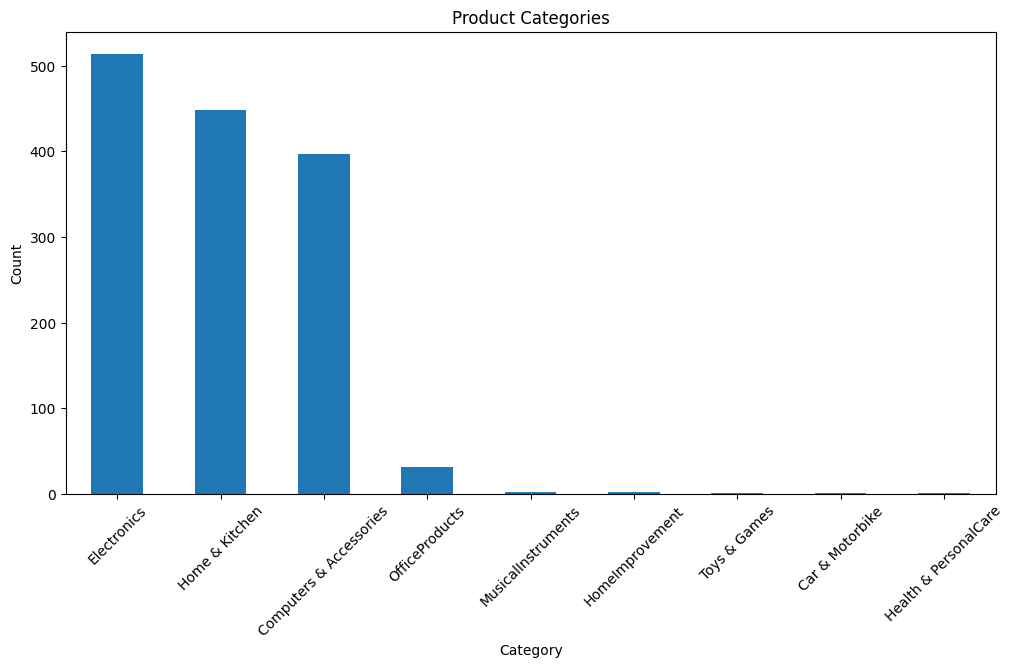

In [413]:
import matplotlib.pyplot as plt

category_counts=amzn["category"].str.split("|",expand=True)
category_counts.rename(columns={0:'category'},inplace=True)
category_counts=category_counts["category"].str.replace("&"," & ")
amzn.drop(columns=["category"])
amzn["category"]=category_counts

category_vals=category_counts.value_counts()
print(category_vals)
plt.figure(figsize=(12,6))
category_vals.plot(kind="bar")
plt.title("Product Categories")
plt.xlabel("Category")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()


#### Analysis

From the above Bar plot it can been seen that most common product category is `Electronics` with `514` products, whereas the least common product categories are `Toys & Games`, `Car & Motorbike` and `Health & PersonalCare` with `1` product in each of them.

Therefore, if a business has a product-line pertaining to either of these categories, then it can look forward to increase its sales and revenue by making their product-line offering available on Amazon.in

### Discounted Price Distribution

* **Objective**: Analyze the frequency of discounted products across the entire price range.
* **Visualizations**: Histogram of discounted prices

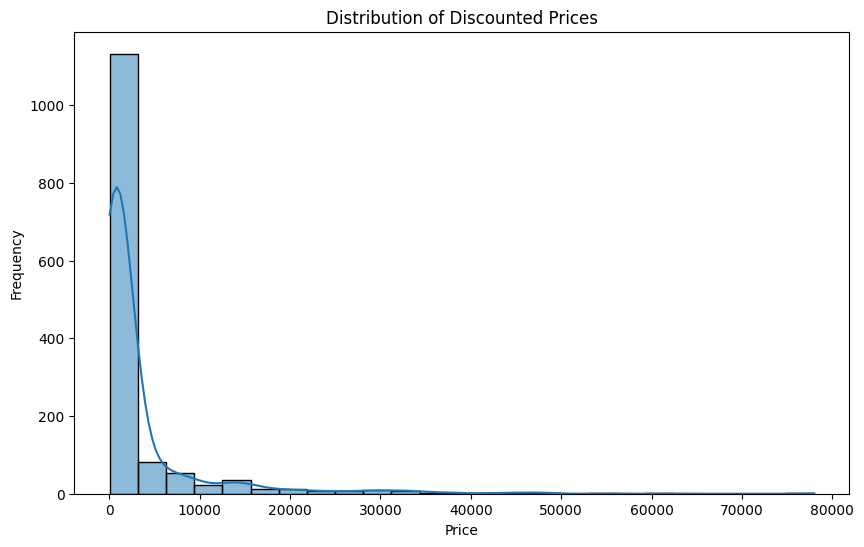

In [414]:
import seaborn as sns
#price distribution
plt.figure(figsize=(10,6))
sns.histplot(amzn["discounted_price"],bins=25,kde=True)
plt.title("Distribution of Discounted Prices")
plt.xlabel("Price")
plt.ylabel("Frequency")
plt.show()

#### Analysis

From the above histogram it can been seen that most of the products with discounted prices occur at a lower price of INR 4000 or less. As we move higher in the price range, the number of products with discounted prices experiences a decline. Hence, it can be said that discounts are highly

This happens because the products at lower price range cater to a mass-market segment. Therefore, various discounts are offered on these products to make them lucrative for customers and stimulate their buying behaviour. 

### Discount by Category Analysis

* **Objective**: Understand the pattern of discount percentages across product categories.
* **Visualizations** - Bar chart of average discount percentage by category

category
HomeImprovement            57.500000
Computers & Accessories    53.763224
Health & PersonalCare      53.000000
Electronics                50.634241
MusicalInstruments         46.000000
Car & Motorbike            42.000000
Home & Kitchen             40.120536
OfficeProducts             12.354839
Toys & Games                0.000000
Name: discount_percentage, dtype: float64


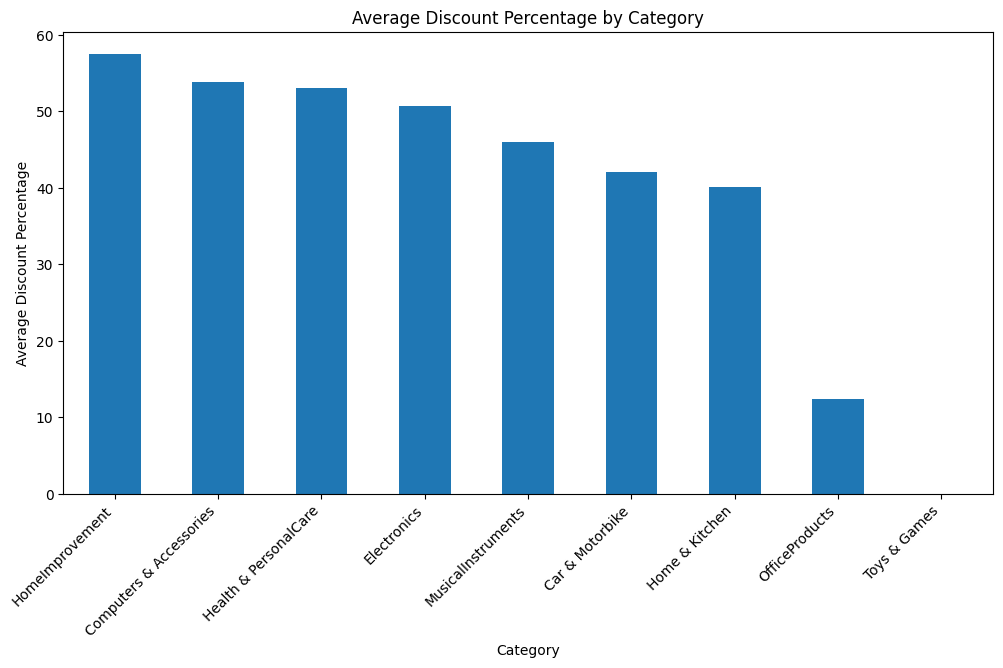

In [415]:
plt.figure(figsize=(12, 6))
amzn.groupby('category')['discount_percentage'].mean().sort_values(ascending=False).plot(kind='bar')
print(amzn.groupby('category')['discount_percentage'].mean().sort_values(ascending=False))
plt.title('Average Discount Percentage by Category')
plt.xlabel('Category')
plt.ylabel('Average Discount Percentage')
plt.xticks(rotation=45, ha='right')
plt.show()

#### Analysis

From the above Bar plot, it can be seen that `Home Improvement` category has the highest average discount percentage of `57.5%` amongst all categories, which are closely followed by `Computers & Accessories (53.76%)` , `Health & Personal Care (53%)` and `Electronics (50.63%)`. 

The above findings signify that these category markets are highly competitive because of which companies offer lucrative discounts.It can also be inferred that these product categories are high margin because of which companies are able to offer high discounts to their customers.  

### Rating Analysis

* Objective: Examine product ratings and their distribution.
* Visualizations:
  * Histogram of product ratings
  * Box plot of ratings by category

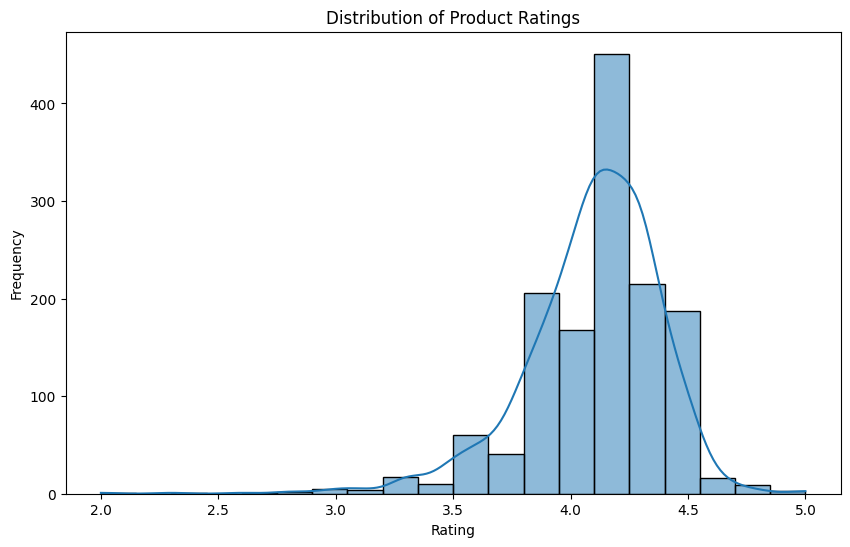

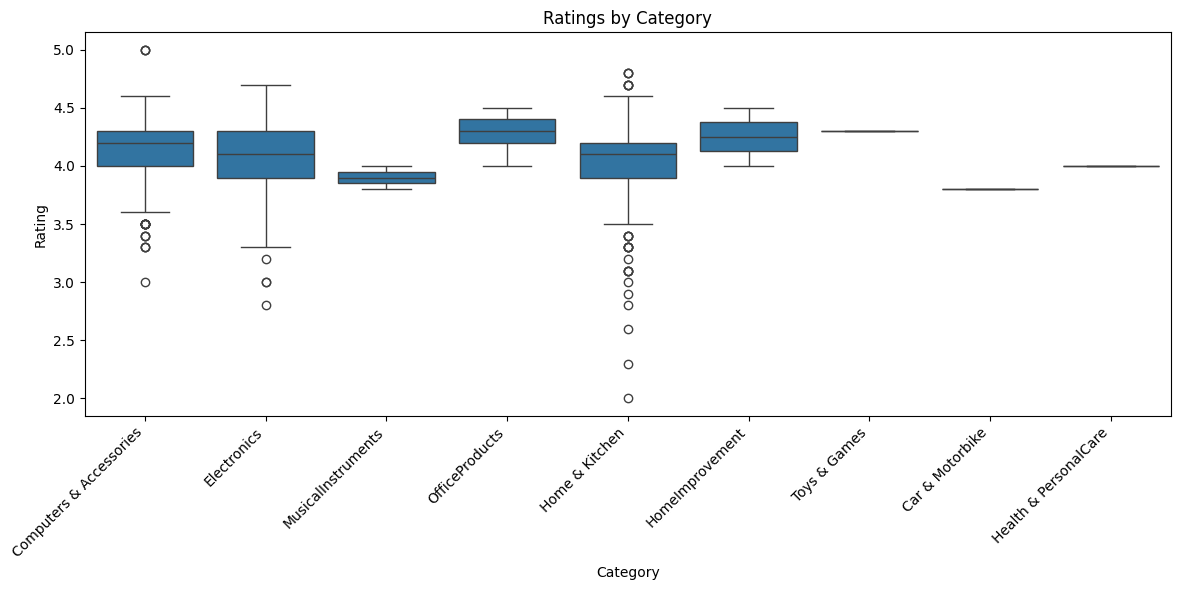

In [416]:
plt.figure(figsize=(10, 6))
sns.histplot(amzn['rating'], bins=20, kde=True)
plt.title('Distribution of Product Ratings')
plt.xlabel('Rating')
plt.ylabel('Frequency')
plt.show()

plt.figure(figsize=(12, 6))
sns.boxplot(x='category', y='rating', data=amzn)
plt.title('Ratings by Category')
plt.xlabel('Category')
plt.ylabel('Rating')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

#### Analysis

In the histogram plot, it can be seen that most of the products (400+) in our dataset have a rating between 4.1 and 4.2. This exhibits that most of the product listings on Amazon are perceived to be of high quality and are highly regarded by customers. 

From the Scatter and Box plot, it can be seen that the categories such as `Computers & Accessories`, `Electronics` and `Home & Kitchen` have a wide spread of ratings, with many reviews being outlier values in these categories. 

Amongst these categories, the `Home & Kitchen` category shows the highest variation in the values of ratings. This would be because of the availability of products belonging to a wide spectrum of quality level.  

### Top Selling Products

**Objective**: Identify the best-selling products based on rating count.

In [417]:
top_products=amzn.groupby("product_name")['rating_count'].sum().sort_values(ascending=False).head(10).astype(int)
print("Top 10 Best Selling Products")
print(top_products)

Top 10 Best Selling Products
product_name
AmazonBasics Flexible Premium HDMI Cable (Black, 4K@60Hz, 18Gbps), 3-Foot                                                                  853945
Amazon Basics High-Speed HDMI Cable, 6 Feet - Supports Ethernet, 3D, 4K video,Black                                                        426973
Amazon Basics High-Speed HDMI Cable, 6 Feet (2-Pack),Black                                                                                 426973
JBL C100SI Wired In Ear Headphones with Mic, JBL Pure Bass Sound, One Button Multi-function Remote, Angled Buds for Comfort fit (Black)    385177
boAt Bassheads 100 in Ear Wired Earphones with Mic(Furious Red)                                                                            363713
boAt Bassheads 100 in Ear Wired Earphones with Mic(Taffy Pink)                                                                             363713
boAt BassHeads 100 in-Ear Wired Headphones with Mic (Black)                       

Above are the Top 10 Best Selling Products on the basis of the given dataset as obtained from Amazon.in. The Top 10 most popular products belong to `Electronics` and `Computer & Accessories` categories. 

The high number of sales for these products can be attributed to the high-quality and cutting-edge technology of these product categories. Products in these categories also belong to a fast paced market as the technology is always evolving, resulting in the faster rollouts of newer versions of these products.

### Correlation Between Rating and Discount

**Objective**: Understand the relationship between product ratings and discount percentages.

In [418]:
# Correlation between rating and discount
correlation = amzn['rating'].corr(amzn['discount_percentage'])
print(f"\nCorrelation between Rating and Discount Percentage: {correlation}")


Correlation between Rating and Discount Percentage: -0.15995020871000934


#### Analysis

Overall, there is a weak negative correlation (-16%) between Rating of the products and discount percentages offered. The weak negative correlation may imply that there might be a slight indication of Higher Ratings associated with Lower Discount Percentages and vice-versa.

### Price Elasticity

**Objective**: Estimate price elasticity to understand how changes in price affect demand (Product Rating)

In [419]:
# Price elasticity (simplified)
amzn['price_elasticity'] = (amzn['rating_count'] - amzn['rating_count'].mean()) / (amzn['discounted_price'] - amzn['discounted_price'].mean())
avg_elasticity_by_category = amzn.groupby('category')['price_elasticity'].mean().sort_values(ascending=True)
print("\nAverage Price Elasticity by Category:")
print(avg_elasticity_by_category)

amzn_new=amzn.copy()


Average Price Elasticity by Category:
category
MusicalInstruments        -10.608206
Electronics                -4.608921
Home & Kitchen             -4.564452
Computers & Accessories    -0.527759
Toys & Games                0.845494
OfficeProducts              4.723124
HomeImprovement             4.918129
Health & PersonalCare       6.338355
Car & Motorbike            19.349663
Name: price_elasticity, dtype: float64


#### Analysis

From the above results, it can be inferred that as the price for each category increases, the demand for products in categories such `Musical Instruments`, `Electronics` and `Home & Kitchen` decline. On the contrary it increases for categories such as `Office Products`, `Home Improvement`, `Health & Personal Care` and `Car & Motorbike`.

While, the negative price elasticity is understood, the positive price elasticity can be attributed to higher quality of products at higher price points, which stimulates customer to move towards higher price range even if it means an increase in the price.

## Topic Modelling Analysis

### Data Preprocessing and Vectorization 

Before proceeding to the Topic Modelling Analysis, we will do slight preparation by removing commas (',') from columns pertaining to reviews and then we would combine the `review_title` and `review_content` columns into `full_review` column.

We then use TF-IDF (Term Frequency-Inverse Document Frequency) vectorization to convert the text data into numerical format. This method:
* Emphasizes important words by giving higher weights to terms that are frequent in a particular review but rare across all reviews.
* Reduces the impact of common words that don't carry much meaning.
* Limits the vocabulary to the 1000 most significant terms, balancing between capturing important information and reducing computational complexity.

In [422]:
amzn['user_id']=amzn['user_id'].str.replace(","," ")
amzn['review_title']=amzn['review_title'].str.replace(","," ")
amzn['review_content']=amzn['review_content'].str.replace(","," ")

from sklearn.feature_extraction.text import TfidfVectorizer

amzn["full_review"]=amzn["review_title"]+" "+amzn["review_content"]
tfidf=TfidfVectorizer(max_features=1000,stop_words='english')
tfidf_matrix=tfidf.fit_transform(amzn['full_review'])
amzn.head()

,product_id,product_name,category,discounted_price,actual_price,discount_percentage,rating,rating_count,user_id,review_title,review_content,price_elasticity,full_review
0,B07JW9H4J1,Wayona Nylon Braided USB to Lightning Fast Cha...,Computers & Accessories,399.0,1099.0,64.0,4.2,24269.0,AG3D6O4STAQKAY2UVGEUV46KN35Q AHMY5CWJMMK5BJRBB...,Satisfied Charging is really fast Value for mo...,Looks durable Charging is fine tooNo complains...,-2.041792,Satisfied Charging is really fast Value for mo...
1,B098NS6PVG,Ambrane Unbreakable 60W / 3A Fast Charging 1.5...,Computers & Accessories,199.0,349.0,43.0,4.0,43994.0,AECPFYFQVRUWC3KGNLJIOREFP5LQ AGYYVPDD7YG7FYNBX...,A Good Braided Cable for Your Type C Device Go...,I ordered this cable to connect my phone to An...,-8.402052,A Good Braided Cable for Your Type C Device Go...
2,B096MSW6CT,Sounce Fast Phone Charging Cable & Data Sync U...,Computers & Accessories,199.0,1899.0,90.0,3.9,7928.0,AGU3BBQ2V2DDAMOAKGFAWDDQ6QHA AESFLDV2PT363T2AQ...,Good speed for earlier versions Good Product W...,Not quite durable and sturdy https://m.media-a...,3.473156,Good speed for earlier versions Good Product W...
3,B08HDJ86NZ,boAt Deuce USB 300 2 in 1 Type-C & Micro USB S...,Computers & Accessories,329.0,699.0,53.0,4.2,94363.0,AEWAZDZZJLQUYVOVGBEUKSLXHQ5A AG5HTSFRRE6NL3M5S...,Good product Good one Nice Really nice product...,Good product long wire Charges good Nice I bou...,-26.104077,Good product Good one Nice Really nice product...
4,B08CF3B7N1,Portronics Konnect L 1.2M Fast Charging 3A 8 P...,Computers & Accessories,154.0,399.0,61.0,4.2,16905.0,AE3Q6KSUK5P75D5HFYHCRAOLODSA AFUGIFH5ZAFXRDSZH...,As good as original Decent Good one for second...,Bought this instead of original apple does th...,0.509806,As good as original Decent Good one for second...


### Topic Modeling with Latent Dirichlet Allocation (LDA)

LDA is used for topic modeling, which helps discover abstract topics in a collection of documents. By setting `n_components=5`, we're asking the model to identify 5 main topics in the reviews. This number can be adjusted based on the diversity of products and reviews in the dataset.

In [423]:
from sklearn.decomposition import LatentDirichletAllocation

lda=LatentDirichletAllocation(n_components=5, random_state=50)
lda.fit(tfidf_matrix)

LatentDirichletAllocation(n_components=5, random_state=50)

### Result Interpretation

Now we print top 10 words for each identified topic.

In [424]:
feature_names = tfidf.get_feature_names_out()
for topic_idx, topic in enumerate(lda.components_):
    top_words = [feature_names[i] for i in topic.argsort()[:-10 - 1:-1]]
    print(f"Topic {topic_idx + 1}: {', '.join(top_words)}")

Topic 1: cable, charging, good, product, fast, usb, quality, charger, nice, working
Topic 2: good, tv, sound, quality, phone, camera, battery, product, picture, price
Topic 3: good, product, use, easy, nice, quality, money, price, water, value
Topic 4: keyboard, keys, printer, typing, key, bar, wrist, print, connects, download
Topic 5: watch, battery, good, phone, features, smart, calling, smartwatch, life, faces


### Topic-by-Topic Analysis

#### Topic 1: Charging Accessories

**Key words**: cable, charging, good, product, fast, usb, quality, charger, nice, working

This topic clearly revolves around charging accessories, particularly USB cables and chargers.

**Insights**:
* Customers frequently mention quality and speed (factors pertaining so speed such as "good", "fast", "quality"), indicating these are crucial factors in charging products.
* The term "working" suggests that functionality is a key concern, possibly implying that users have experienced non-functional products in the past.

**Business Implications**:
* Quality control is vital for charging accessories.
* Marketing should emphasize speed and reliability.
* There may be an opportunity to develop premium, high-speed charging products.

#### Topic 2: Entertainment and Communication Devices

**Key words**: good, tv, sound, quality, phone, camera, battery, product, picture, price

This topic covers a range of electronic devices, including TVs, phones, and cameras.

**Insights**:
* Quality is mentioned in relation to both sound and picture, highlighting the importance of sensory experience in these products.
* Battery life appears to be a significant factor for portable devices.
* Price is included, suggesting that customers are price-sensitive in this category.

**Business Implications**:
* Focus on improving audio-visual quality in TVs and phones.
* Invest in battery technology for mobile devices.
* Consider competitive pricing strategies while maintaining quality.

#### Topic 3: General Product Satisfaction and Value

**Key words**: good, product, use, easy, nice, quality, money, price, water, value

This topic seems to cover general product satisfaction across various categories.

**Insights**:
* Ease of use is a recurring theme ("easy", "use").
* Value for money is clearly important ("money", "price", "value").
* The mention of "water" could indicate water-resistance as a valued feature in some products.

**Business Implications**:
* Emphasize user-friendliness in product design and marketing.
* Ensure products offer good value for money.
* Consider expanding water-resistant product lines.

#### Topic 4: Computer Peripherals and Software

**Key words**: keyboard, keys, printer, typing, key, bar, wrist, print, connects, download

This topic is focused on computer accessories, particularly keyboards and printers.

**Insights**:
* Ergonomics seems to be important ("wrist"), likely referring to wrist rests for keyboards.
* Connectivity is a key feature ("connects", "download").
* The typing experience is crucial for keyboards.

**Business Implications**:
* Invest in ergonomic designs for computer peripherals.
* Ensure seamless connectivity and easy setup for printers and keyboards.
* Focus on improving the typing experience in keyboard designs.

#### Topic 5: Smartwatches and Wearables

**Key words**: watch, battery, good, phone, features, smart, calling, smartwatch, life, faces

This topic clearly revolves around smartwatches and their features.

**Insights**:
* Battery life is a critical factor for smartwatches.
* Calling features are important, indicating a preference for standalone functionality.
* Customization options, such as face unlock, are valued by users.

**Business Implications**:
* Prioritize battery life improvements in smartwatch development.
* Enhance calling capabilities in smartwatches.
* Focus and Enhance on face lock functionality in smart watches.